In [1]:
# imports
import datetime
import math
import time

import numpy as np
import pyodbc
import pandas as pd
from icecream import ic
from matplotlib import pyplot as plt
from numpy import ndarray
from pandas import DataFrame, Series
from pyodbc import Row

In [2]:
# functions
def time_to_seconds(_time: datetime.time) -> int:
    """
    params:
    _time in [00:00:00, 23:59:59]

    returns:
    out in [0, 86399]
    """
    return _time.hour * 3600 + _time.minute * 60 + _time.second


def seconds_to_time(total_seconds: int) -> datetime.time:
    """
    params:
    total_seconds in [0, 86399]

    returns:
    out in [00:00:00, 23:59:59]
    """
    if not (0 <= total_seconds < 86399):
        raise ValueError

    hour = total_seconds // 3600
    remaining_seconds = total_seconds % 3600

    minute = remaining_seconds // 60
    second = remaining_seconds % 60

    return datetime.time(hour=hour, minute=minute, second=second)


def stack_period(
    period: float | Series,
    size: float | Series,
    x: float | Series,
) -> float | Series:
    """
    purchase_time:
        time user clicked buy

    purchase_time_s:
        purchase_time in seconds since start of day

    purchase_time_dow_s:
        purchase_time in seconds since start of week
        ((day_of_week - 1) * 86400) + purchase_time_s
    """
    return ((period - 1) * size) + x


def format_time_to_ms(_time: float) -> str:
    return f"{_time * 1000:.2f}ms"


def format_time(seconds: float) -> str:
    log_seconds: float = math.log10(seconds)

    match log_seconds:
        case _ if 0 <= log_seconds:
            return f"{seconds:.2f}s"

        case _ if -3 <= log_seconds < 0:
            return f"{seconds * 1000:.2f}ms"

        case _:
            return "<000.00ms"

In [3]:
# configs
name_map: dict[str, str] = {
    "dow": "day_of_week",
    "dom": "day_of_month",
    "doy": "day_of_year",
    "wn": "week_number",
    "mn": "month_number",
    "qn": "quarter_number",
    "yn": "year_number",
}


def sql_grain_pt(grain: str) -> str:
    return f"""
    SELECT
        o.{grain},
        CONVERT(TIME, o.order_purchase_timestamp) AS purchase_time,
        DATEDIFF(SECOND, o.order_purchase_timestamp, order_approved_at)
            AS diff_purchase_to_approve_s,
        COUNT(*) AS order_count
    FROM sales.vw_orders_practical AS o
    GROUP BY
        o.{grain},
        CONVERT(TIME, o.order_purchase_timestamp),
        DATEDIFF(SECOND, o.order_purchase_timestamp, order_approved_at)
    ORDER BY
        o.{grain},
        purchase_time,
        diff_purchase_to_approve_s
    """


sql_day_pt = """
    SELECT
        CONVERT(TIME, o.order_purchase_timestamp) AS purchase_time,
        COUNT(*) AS order_count
    FROM sales.vw_orders_practical AS o
    GROUP BY CONVERT(TIME, o.order_purchase_timestamp)
    ORDER BY purchase_time;
"""

# connect
driver = "ODBC Driver 17 for SQL Server"
server = "localhost"
database = "olist"

connstring: str = f"""
    DRIVER={{{driver}}};
    SERVER={server};
    DATABASE={database};
    Trusted_Connection=yes;
"""
tik_connect = time.perf_counter()
conn = pyodbc.connect(connstring, timeout=60)
cursor = conn.cursor()
tok_connect = time.perf_counter()

# get day table
tik_day_table = time.perf_counter()
day_pt_rows: list[Row] = cursor.execute(sql_day_pt).fetchall()

day_pt_columns: list[str] = [description[0] for description in cursor.description]
df_day_pt: DataFrame = pd.DataFrame(
    (tuple(r) for r in day_pt_rows), columns=day_pt_columns
)
tok_day_table = time.perf_counter()

# get other tables
tik_other_tables = time.perf_counter()
dfs_pt: dict[str, DataFrame] = {}

for name in name_map:
    df_name = f"{name}"
    grain = name_map[name]

    sql = sql_grain_pt(grain=grain)
    grain_pt_rows: list[Row] = cursor.execute(sql).fetchall()

    grain_pt_columns: list[str] = [description[0] for description in cursor.description]
    df_grain_pt = pd.DataFrame(
        (tuple(r) for r in grain_pt_rows), columns=grain_pt_columns
    )

    dfs_pt[df_name] = df_grain_pt
tok_other_tables = time.perf_counter()

conn.close()

print(f"Time to connect to DB: {format_time_to_ms(tok_connect - tik_connect)}")
print(f"Query day table: {format_time_to_ms(tok_day_table - tik_day_table)}")
print(f"Query other tables: {format_time_to_ms(tok_other_tables - tik_other_tables)}")

Time to connect to DB: 183.18ms
Query day table: 521.77ms
Query other tables: 3596.91ms


In [4]:
# clean
time_s_column_name = "purchase_time_s"

tik_day = time.perf_counter()
if not df_day_pt.columns.str.contains(time_s_column_name).any():
    df_day_pt[time_s_column_name] = df_day_pt["purchase_time"].apply(time_to_seconds)
tok_day = time.perf_counter()

tik_other = time.perf_counter()
for i in dfs_pt:
    if not dfs_pt[i].columns.str.contains(time_s_column_name).any():
        dfs_pt[i][time_s_column_name] = dfs_pt[i]["purchase_time"].apply(
            time_to_seconds
        )

    if not dfs_pt[i].columns.str.contains("stack_s").any():
        dfs_pt[i]["stack_s"] = stack_period(
            dfs_pt[i][name_map[i]], 86400, dfs_pt[i][time_s_column_name]
        )
        pass


tok_other = time.perf_counter()

print(f"Clean df_pt_day: {format_time_to_ms(tok_day - tik_day)}")
print(f"Clean dfs_pt: {format_time_to_ms(tok_other - tik_other)}")

Clean df_pt_day: 24.74ms
Clean dfs_pt: 324.05ms


In [5]:
day_in_s = 86400
year_in_s = day_in_s * 365.25
measures: dict[str, float] = {
    "s": 1,
    "m": 60,
    "h": 3600,
    "d": day_in_s,
    "w": day_in_s * 7,
    "M": year_in_s / 12,
    "q": year_in_s / 4,
    "y": year_in_s,
}


def _split_duration(duration: str) -> tuple[float, str]:
    measure: str = duration[-1]
    _number_part: str = duration[:-1]
    number: float = 1 if len(_number_part) == 0 else float(_number_part)

    return number, measure


def _duration_s(duration: str) -> float:
    number, measure = _split_duration(duration)
    return number * measures[measure]


def time_ratio(chunk: str, whole: str = "d") -> float:
    """
    Solves the question: 'How many 15m chunks in a day?'
    How many {chunk} chunks in a {whole}
    Also: 'How many days in a 15m chunk'

    Chunk format like: '15m', '1h', '12h'
    whole format like: 'd', '1d'
    """
    chunk_number_s: float = _duration_s(chunk)
    whole_number_s: float = _duration_s(whole)

    tratio: float = whole_number_s / chunk_number_s
    return tratio


def time_div(part: str, whole: str, step: str = "s") -> ndarray:
    part_number_s: float = _duration_s(part)
    whole_number_s: float = _duration_s(whole)
    step_number_s: float = _duration_s(step)

    tratio: float = whole_number_s / part_number_s

    return step_number_s * part_number_s * np.arange(tratio)


def bins_tratio(*args: str) -> int:
    tratio = time_ratio(*args)
    return math.floor(tratio)

In [6]:
padding = 1.1
vline_padding = 1.5

h3_starts = time_div("3h", "d")
h3_mid = (h3_starts[0] + h3_starts[1]) / 2
h3_mids = h3_starts + h3_mid
h3_names = [
    "00:00",
    "03:00",
    "06:00",
    "09:00",
    "12:00",
    "15:00",
    "18:00",
    "21:00",
]

weekday_starts = time_div("d", "w")
weekday_mid = (weekday_starts[0] + weekday_starts[1]) / 2
weekday_mids = weekday_starts + weekday_mid
weekday_names = [
    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun",
]


month_starts = time_div("M", "y")
month_mid = (month_starts[0] + month_starts[1]) / 2
month_mids = month_starts + month_mid
month_names = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

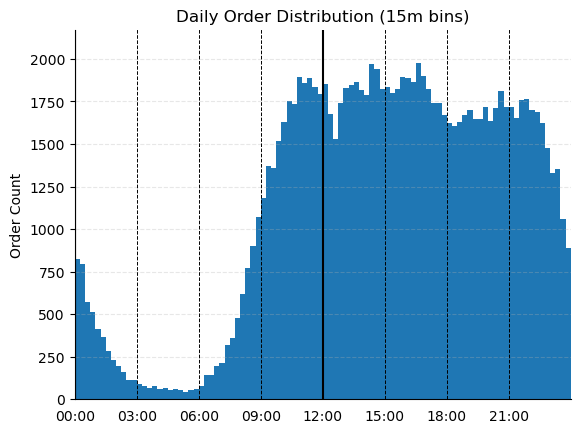

In [7]:
bin_size = "15m"

_data = df_day_pt
x = _data["purchase_time_s"]
weights = _data["order_count"]

fig, ax = plt.subplots()
y, _, _ = ax.hist(x, weights=weights, bins=bins_tratio(bin_size))
ymax = y.max() * vline_padding

ax.vlines(
    time_div("3h", "d"),
    ymin=0,
    ymax=ymax,
    colors="black",
    linestyles="--",
    linewidth=0.7,
)
ax.vlines(
    time_div("12h", "d"),
    ymin=0,
    ymax=ymax,
    colors="black",
)

ax.xaxis.set_ticks_position("none")
plt.xticks(ticks=h3_starts, labels=h3_names)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(0, x.max())
plt.ylim(0, y.max() * padding)

plt.ylabel("Order Count")

plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.title(f"Daily Order Distribution ({bin_size} bins)")
plt.show()

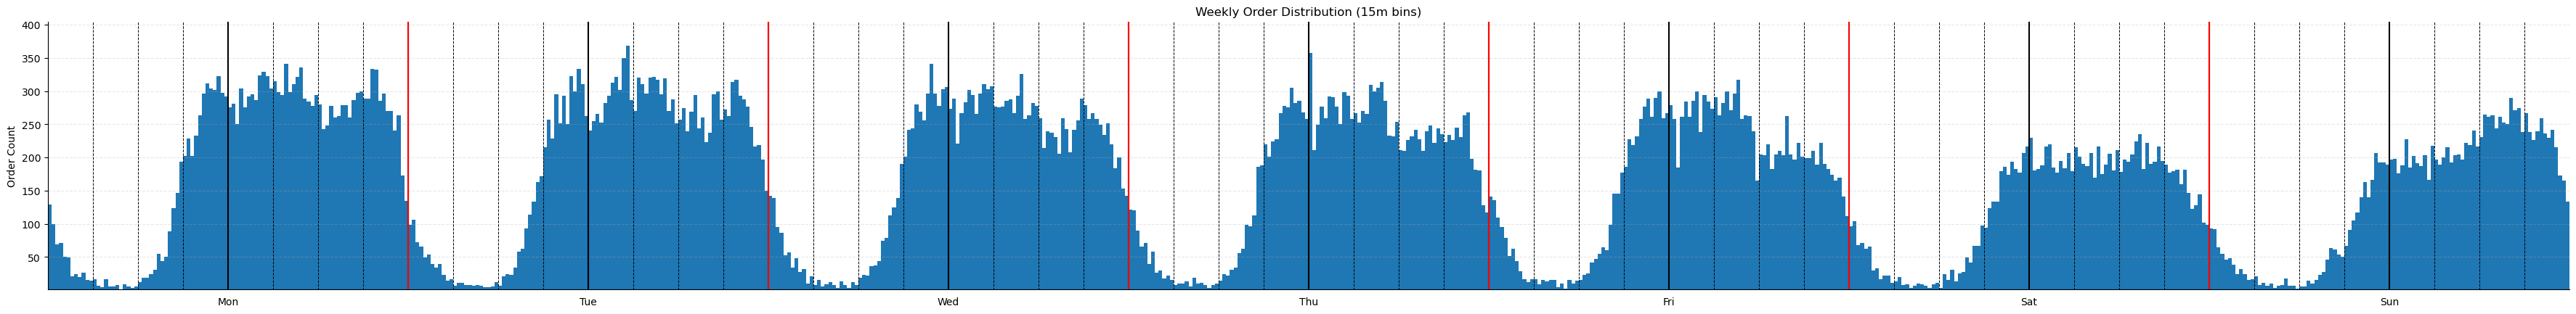

In [8]:
bin_size = "15m"

_data = dfs_pt["dow"]
x = _data["stack_s"]
weights = _data["order_count"]

fig, ax = plt.subplots()
y, _, _ = ax.hist(x, weights=weights, bins=bins_tratio(bin_size, "w"))
ymax = y.max() * vline_padding

ax.vlines(
    time_div("3h", "w"),
    ymin=0,
    ymax=ymax,
    colors="black",
    linestyles="--",
    linewidth=0.7,
)
ax.vlines(
    time_div("12h", "w"),
    ymin=0,
    ymax=ymax,
    colors="black",
)
ax.vlines(
    time_div("d", "w"),
    ymin=0,
    ymax=ymax,
    colors="red",
)

ax.xaxis.set_ticks_position("none")
plt.xticks(ticks=weekday_mids, labels=weekday_names)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(x.min(), x.max())
plt.ylim(y.min(), y.max() * padding)

plt.ylabel("Order Count")

plt.title(f"Weekly Order Distribution ({bin_size} bins)")

fig.set_figwidth(fig.get_figwidth() * 7)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.show()

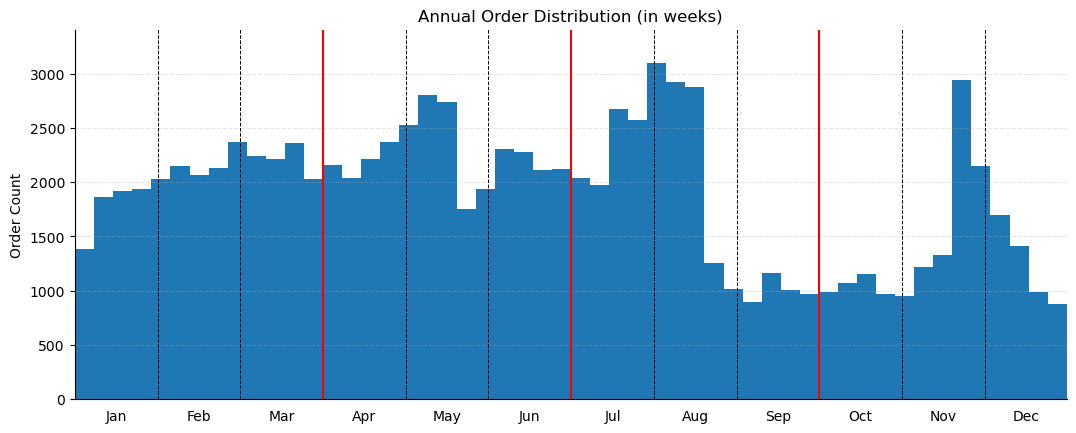

In [9]:
_data = dfs_pt["doy"]
x = _data["stack_s"]
weights = _data["order_count"]

fig, ax = plt.subplots()
y, _, _ = ax.hist(x, bins=bins_tratio("w", "y"))
ymax = y.max() * vline_padding

ax.vlines(
    time_div("M", "y"),
    ymin=0,
    ymax=ymax,
    colors="black",
    linestyles="--",
    linewidth=0.7,
)
ax.vlines(
    time_div("q", "y"),
    ymin=0,
    ymax=ymax,
    colors="red",
)

ax.xaxis.set_ticks_position("none")
plt.xticks(ticks=month_mids, labels=month_names)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(0, x.max())
plt.ylim(0, y.max() * padding)

plt.ylabel("Order Count")

plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.title("Annual Order Distribution (in weeks)")

fig.set_figwidth(fig.get_figwidth() * 2)
plt.show()